In [1]:
%matplotlib widget
import torch
import os
import copy
import matplotlib.pyplot as plt
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm
if torch.cuda.is_available():
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

from diffSPH.simple import *
from diffSPH.reference.sod import buildSod_reference, sodInitialState, generateSod1D, plotSod

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32

In [2]:
nx = 800
dim = 1
gamma = 5/3 # Equation of State parameter

initialStateLeft = sodInitialState(1, 1, 0) # Pressure Density Velocity
initialStateRight = sodInitialState(0.1795, 0.25, 0)
ratio = 1 # Sampling density ratio for adaptive simulations
smoothIC = False # If the initial conditions should be smoothed out
timeLimit = 0.15

domain = buildDomainDescription(l = 2, dim = 1, periodic = True, device = device, dtype = dtype)

In [3]:
targetNeighbors = n_h_to_nH(4, 1)

kernel = KernelType.B7
scheme = SimulationScheme.CompSPH
integrationScheme = IntegrationSchemeType.rungeKutta2
viscositySwitch = ViscositySwitch.NoneSwitch
supportScheme = AdaptiveSupportScheme.NoScheme


In [4]:
simulator, SimulationSystem, solverConfig, integrator = getSimulationScheme(
     scheme, kernel, integrationScheme, 
     gamma, targetNeighbors, domain, 
     viscositySwitch=viscositySwitch, supportScheme = supportScheme)
particleSystem = generateSod1D(nx, ratio, initialStateLeft, initialStateRight, gamma, solverConfig['kernel'], targetNeighbors, dtype, device, smoothIC, SimulationSystem)


dt = computeTimestep(scheme, 1e-3, particleSystem.systemState, solverConfig, None)
timesteps = int(timeLimit / dt)

In [5]:
simulationState = copy.deepcopy(particleSystem)
simulationState.systemState.divergence = torch.zeros_like(simulationState.systemState.densities)
states = []


for i in (tq:=tqdm(range(timesteps))):
    simulationState, currentState, updates = integrator.function(simulationState, dt, simulator, solverConfig, priorStep = simulationState.priorStep)
    simulationState.priorStep = [updates[-1], currentState[-1]]
    
    states.append(copy.deepcopy(simulationState))

  0%|          | 0/832 [00:00<?, ?it/s]

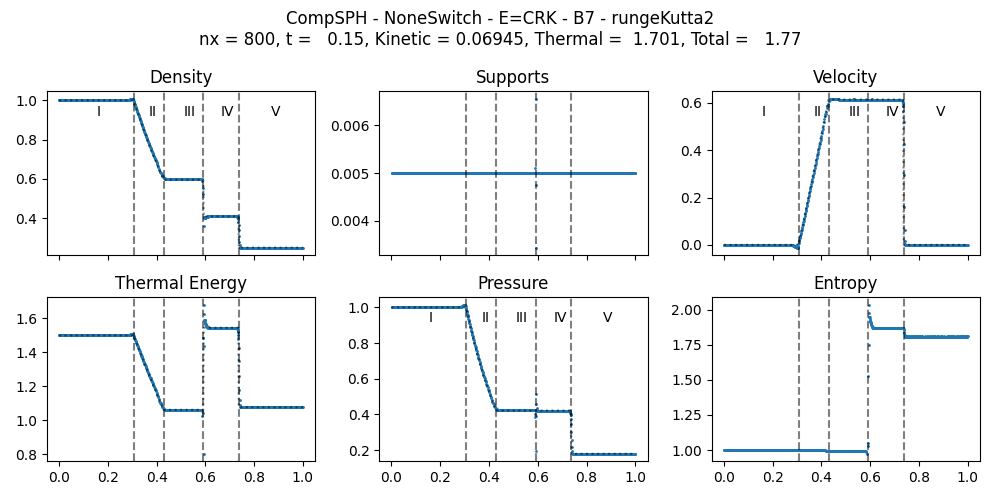

In [6]:
plotSod(states[-1], solverConfig, states[0].domain, gamma, initialStateLeft, initialStateRight, plotReference = True, plotLabels = True, scatter = True)

In [ ]:
referenceState = copy.deepcopy(states[-1])

In [8]:
config2 = copy.deepcopy(solverConfig)

gamma = torch.tensor([2], dtype=dtype, device=device)
gamma.requires_grad_()

config2['fluid']['gamma'] = gamma

In [9]:
simulationState = copy.deepcopy(particleSystem)
simulationState.systemState.divergence = torch.zeros_like(simulationState.systemState.densities)
states = []


for i in (tq:=tqdm(range(timesteps))):
    simulationState, currentState, updates = integrator.function(simulationState, dt, simulator, config2, priorStep = simulationState.priorStep)
    simulationState.priorStep = [updates[-1], currentState[-1]]
    
    states.append(copy.deepcopy(simulationState.nograd()))

  0%|          | 0/832 [00:00<?, ?it/s]

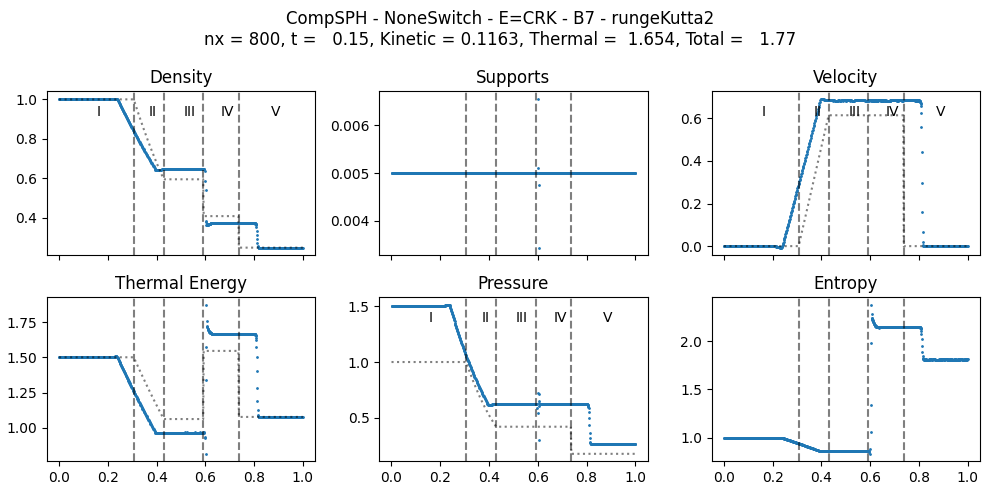

In [10]:
plotSod(states[-1].nograd(), solverConfig, states[0].domain, solverConfig['fluid']['gamma'], initialStateLeft, initialStateRight, plotReference = True, plotLabels = True, scatter = True)

In [11]:
simulationState = copy.deepcopy(particleSystem)
simulationState.systemState.divergence = torch.zeros_like(simulationState.systemState.densities)
states = []

gamma = torch.tensor([2], dtype=dtype, device=device)
gamma.requires_grad_()
gammaIterations = []

optimizer = torch.optim.Adam([gamma], lr = 1e-2)

In [ ]:
for i in (tq:=tqdm(range(1024))):
    optimizer.zero_grad()
    solverConfig['fluid']['gamma'] = gamma
    simulationState = copy.deepcopy(particleSystem)
    simulationState.systemState.divergence = torch.zeros_like(simulationState.systemState.densities)

    for i in (t:=tqdm(range(timesteps), leave=False)):
        simulationState, currentState, updates = integrator.function(simulationState, dt, simulator, solverConfig, priorStep = simulationState.priorStep)
        simulationState.priorStep = [updates[-1], currentState[-1]]
        
    velocityLoss = torch.mean((simulationState.systemState.velocities - referenceState.systemState.velocities)**2)
    velocityLoss.backward()

    optimizer.step()

    tq.set_postfix({
        'Loss': velocityLoss.item(),
        'gamma': gamma.detach().cpu().item(),
        'gamma grad': gamma.grad.detach().cpu().item(),
    })
    gammaIterations.append(gamma.detach().cpu().numpy().copy())

    if i > 2: 
        break

  0%|          | 0/1024 [00:00<?, ?it/s]

  0%|          | 0/832 [00:00<?, ?it/s]

  0%|          | 0/832 [00:00<?, ?it/s]

  0%|          | 0/832 [00:00<?, ?it/s]

  0%|          | 0/832 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [19]:
def runSimulation(timesteps, particleSystem, solverConfig, withGradients = False):
    simulationState = copy.deepcopy(particleSystem)
    simulationState.systemState.divergence = torch.zeros_like(simulationState.systemState.densities)
    states = []

    for i in (tq:=tqdm(range(timesteps), leave = False)):
        simulationState, currentState, updates = integrator.function(simulationState, dt, simulator, solverConfig, priorStep = simulationState.priorStep)
        simulationState.priorStep = [updates[-1], currentState[-1]]
        if not withGradients:
            states.append(copy.deepcopy(simulationState))
        else:
            states.append(copy.deepcopy(simulationState.nograd()))

    return states, simulationState

In [24]:
targetSteps = 50

referenceState = runSimulation(targetSteps, particleSystem, solverConfig, withGradients = False)[1]

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
config2 = copy.deepcopy(solverConfig)
gamma = torch.tensor([2], dtype=dtype, device=device)
gamma.requires_grad_()
gammaIterations = []

optimizer = torch.optim.Adam([gamma], lr = 1e-2)

for i in (tq:=tqdm(range(1024))):
    optimizer.zero_grad()
    config2['fluid']['gamma'] = gamma
    simulationState = copy.deepcopy(particleSystem)
    simulationState.systemState.divergence = torch.zeros_like(simulationState.systemState.densities)


    states, simulationState = runSimulation(targetSteps, simulationState, config2, withGradients = True)
        
    velocityLoss = torch.mean((simulationState.systemState.velocities - referenceState.systemState.velocities)**2)
    velocityLoss.backward()

    optimizer.step()

    tq.set_postfix({
        'Loss': velocityLoss.item(),
        'gamma': gamma.detach().cpu().item(),
        'gamma grad': gamma.grad.detach().cpu().item(),
    })
    gammaIterations.append(gamma.detach().cpu().numpy().copy())

    if velocityLoss.item() < 1e-6:
        break


  0%|          | 0/1024 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

RuntimeError: The following operation failed in the TorchScript interpreter.
Traceback of TorchScript (most recent call last):
RuntimeError: 


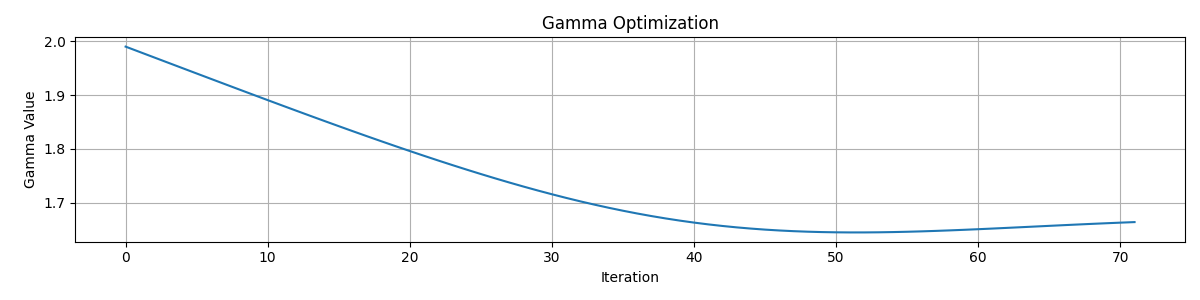

In [28]:
fig, axis = plt.subplots(1, 1, figsize=(12, 3))
axis.plot(gammaIterations)
axis.set_title('Gamma Optimization')
axis.set_xlabel('Iteration')
axis.set_ylabel('Gamma Value')
axis.grid(True)
fig.tight_layout()


In [30]:
torch.cuda.empty_cache()

In [31]:
targetSteps = 832

referenceState = runSimulation(targetSteps, particleSystem, solverConfig, withGradients = False)[1]

config2 = copy.deepcopy(solverConfig)
gamma = torch.tensor([2], dtype=dtype, device=device)
gamma.requires_grad_()
gammaIterationsFull = []

optimizer = torch.optim.Adam([gamma], lr = 1e-2)

for i in (tq:=tqdm(range(100))):
    optimizer.zero_grad()
    config2['fluid']['gamma'] = gamma
    simulationState = copy.deepcopy(particleSystem)
    simulationState.systemState.divergence = torch.zeros_like(simulationState.systemState.densities)


    states, simulationState = runSimulation(targetSteps, simulationState, config2, withGradients = True)
        
    velocityLoss = torch.mean((simulationState.systemState.velocities - referenceState.systemState.velocities)**2)
    velocityLoss.backward()

    optimizer.step()

    tq.set_postfix({
        'Loss': velocityLoss.item(),
        'gamma': gamma.detach().cpu().item(),
        'gamma grad': gamma.grad.detach().cpu().item(),
    })
    gammaIterationsFull.append(gamma.detach().cpu().numpy().copy())

    if velocityLoss.item() < 1e-6:
        break


  0%|          | 0/832 [00:00<?, ?it/s]

  0%|          | 0/1024 [00:00<?, ?it/s]

  0%|          | 0/832 [00:00<?, ?it/s]

  0%|          | 0/832 [00:00<?, ?it/s]

  0%|          | 0/832 [00:00<?, ?it/s]

...

  0%|          | 0/832 [00:00<?, ?it/s]

  0%|          | 0/832 [00:00<?, ?it/s]

  0%|          | 0/832 [00:00<?, ?it/s]

  0%|          | 0/832 [00:00<?, ?it/s]

  0%|          | 0/832 [00:00<?, ?it/s]

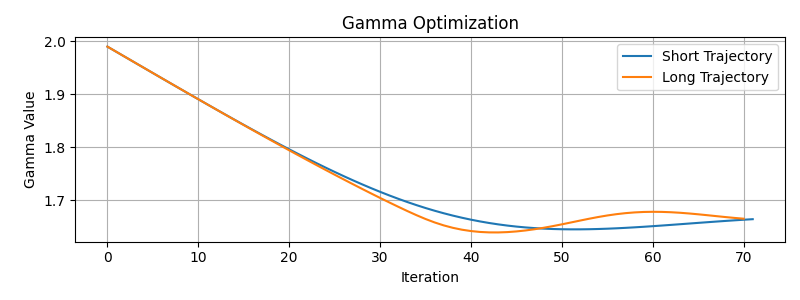

In [34]:
fig, axis = plt.subplots(1, 1, figsize=(8, 3))
axis.plot(gammaIterations, label = 'Short Trajectory')
axis.plot(gammaIterationsFull, label = 'Long Trajectory')
axis.set_title('Gamma Optimization')
axis.set_xlabel('Iteration')
axis.set_ylabel('Gamma Value')
axis.grid(True)
axis.legend()
fig.tight_layout()
